# Association Rule Mining with Groceries Dataset


In [6]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
groceries_df = pd.read_csv('LECTURE NOTES AND PRACTICUM-20250911/Groceries_dataset.csv')

groceries_df.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [ ]:
#group items by transaction
transactions = groceries_df.groupby('Member_number')['itemDescription'].apply(list).tolist()

te = TransactionEncoder()
te_ary = te.fit_transform(transactions)
groceries_encoded = pd.DataFrame(te_ary, columns=te.columns_)
groceries_encoded.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,True,False,...,False,False,False,True,False,True,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [ ]:

frequent_itemsets = apriori(groceries_encoded, min_support=0.02, use_colnames=True)


rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1)


rules.sort_values(by='confidence', ascending=False).head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
2732,"(yogurt, other vegetables, bottled water)",(whole milk),0.032324,0.458184,0.022063,0.682540,1.489664,1.0,0.007252,1.706721,0.339688,0.047097,0.414081,0.365346
1086,"(bottled beer, shopping bags)",(whole milk),0.030272,0.458184,0.020010,0.661017,1.442690,1.0,0.006140,1.598358,0.316429,0.042716,0.374358,0.352345
2844,"(rolls/buns, yogurt, other vegetables)",(whole milk),0.052335,0.458184,0.034377,0.656863,1.433623,1.0,0.010398,1.579008,0.319170,0.072198,0.366691,0.365945
1482,"(canned beer, shopping bags)",(whole milk),0.033607,0.458184,0.022063,0.656489,1.432806,1.0,0.006664,1.577287,0.312574,0.046969,0.366000,0.352320
2887,"(yogurt, other vegetables, soda)",(whole milk),0.043099,0.458184,0.027963,0.648810,1.416047,1.0,0.008216,1.542799,0.307042,0.059079,0.351827,0.354920


C:\Users\HP\AppData\Local\Temp\ipykernel_18932\3115129836.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=item_counts.values, y=item_counts.index, palette='viridis')


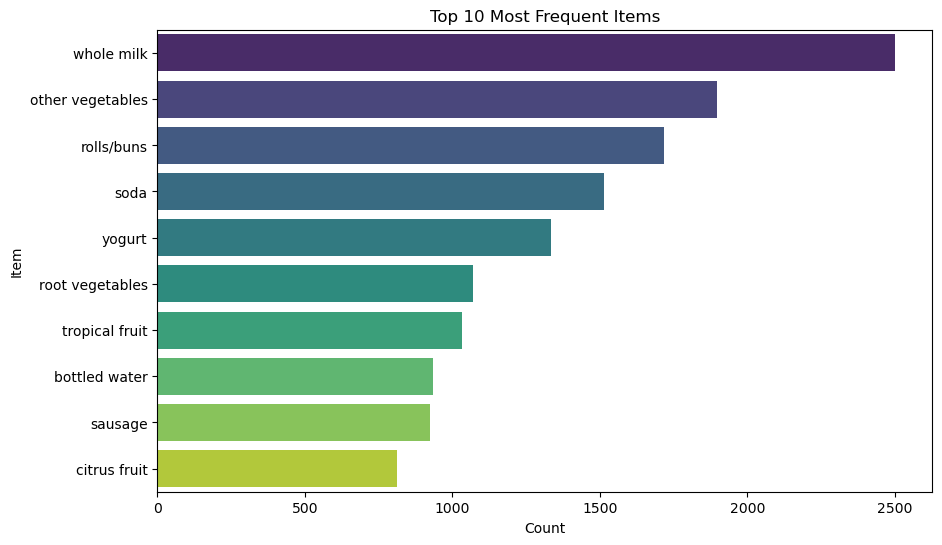

C:\Users\HP\AppData\Local\Temp\ipykernel_18932\3115129836.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_conf['confidence'], y=top_conf['consequents'].astype(str), palette='magma')


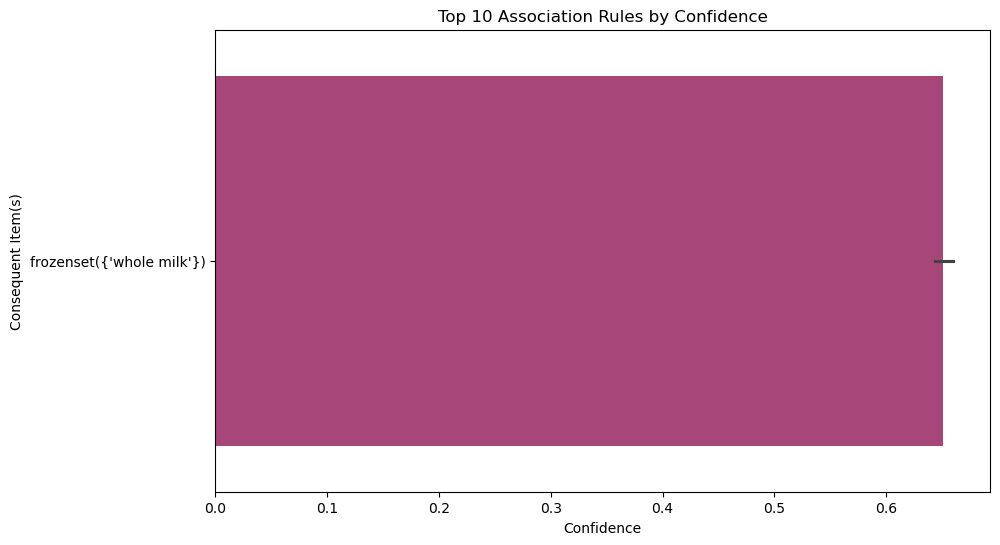

C:\Users\HP\AppData\Local\Temp\ipykernel_18932\3115129836.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_lift['lift'], y=top_lift['consequents'].astype(str), palette='coolwarm')


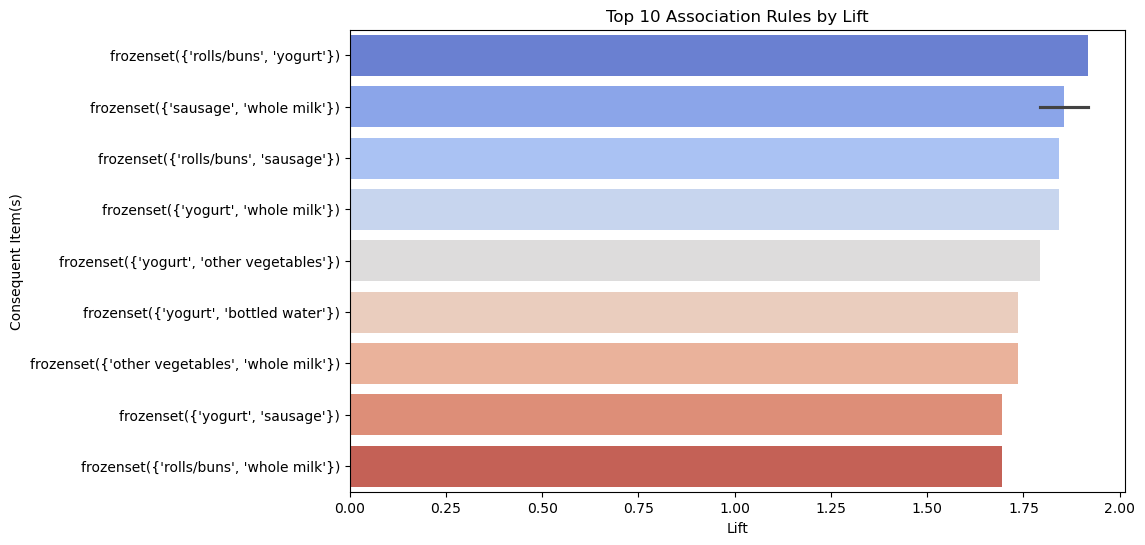

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing the top 10 most frequent items
item_counts = groceries_df['itemDescription'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=item_counts.values, y=item_counts.index, palette='viridis')
plt.title('Top 10 Most Frequent Items')
plt.xlabel('Count')
plt.ylabel('Item')
plt.show()

# Visualizing the top 10 association rules by confidence
if 'confidence' in rules.columns:
    top_conf = rules.sort_values(by='confidence', ascending=False).head(10)
    plt.figure(figsize=(10,6))
    sns.barplot(x=top_conf['confidence'], y=top_conf['consequents'].astype(str), palette='magma')
    plt.title('Top 10 Association Rules by Confidence')
    plt.xlabel('Confidence')
    plt.ylabel('Consequent Item(s)')
    plt.show()

# Visualizing the top 10 association rules by lift
if 'lift' in rules.columns:
    top_lift = rules.sort_values(by='lift', ascending=False).head(10)
    plt.figure(figsize=(10,6))
    sns.barplot(x=top_lift['lift'], y=top_lift['consequents'].astype(str), palette='coolwarm')
    plt.title('Top 10 Association Rules by Lift')
    plt.xlabel('Lift')
    plt.ylabel('Consequent Item(s)')
    plt.show()